# Task 3 - Sentiment Analysis

## Amazon customer reviews
The objective of this project is to analyze Amazon customer reviews and classify them into positive and negative sentiments using Natural Language Processing (NLP) techniques. The goal is to extract meaningful insights from customer feedback to understand overall satisfaction and product perception.

# 1) Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud


nltk.download('vader_lexicon')

sns.set_style("whitegrid")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# 2) Load Dataset

In [23]:
!pip install datasets

from datasets import load_dataset

dataset = load_dataset("amazon_polarity", split="train[:2000]")

df = pd.DataFrame(dataset)

# Keep only relevant columns for sentiment analysis
df = df[['content', 'label']]

df.head()

,content,label
0,This sound track was beautiful! It paints the ...,1
1,I'm reading a lot of reviews saying that this ...,1
2,This soundtrack is my favorite music of all ti...,1
3,I truly like this soundtrack and I enjoy video...,1
4,"If you've played the game, you know how divine...",1


# 3. Dataset Overview

In [3]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  2000 non-null   object
 1   label    2000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


,count
label,
0,1035
1,965


# 4. Data Cleaning

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['cleaned_text'] = df['content'].apply(clean_text)

df.head()



,content,label,cleaned_text,predicted_sentiment,actual_sentiment
0,This sound track was beautiful! It paints the ...,1,this sound track was beautiful it paints the s...,Positive,Positive
1,I'm reading a lot of reviews saying that this ...,1,i m reading a lot of reviews saying that this ...,Positive,Positive
2,This soundtrack is my favorite music of all ti...,1,this soundtrack is my favorite music of all ti...,Positive,Positive
3,I truly like this soundtrack and I enjoy video...,1,i truly like this soundtrack and i enjoy video...,Positive,Positive
4,"If you've played the game, you know how divine...",1,if you ve played the game you know how divine ...,Positive,Positive


# 5. Sentiment Analysis (VADER)

In [5]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['predicted_sentiment'] = df['cleaned_text'].apply(get_sentiment)

df.head()

,content,label,cleaned_text,predicted_sentiment
0,This sound track was beautiful! It paints the ...,1,this sound track was beautiful it paints the ...,Positive
1,I'm reading a lot of reviews saying that this ...,1,i m reading a lot of reviews saying that this ...,Positive
2,This soundtrack is my favorite music of all ti...,1,this soundtrack is my favorite music of all ti...,Positive
3,I truly like this soundtrack and I enjoy video...,1,i truly like this soundtrack and i enjoy video...,Positive
4,"If you've played the game, you know how divine...",1,if you ve played the game you know how divine...,Positive


# 6. Visualization 1: Sentiment Distribution

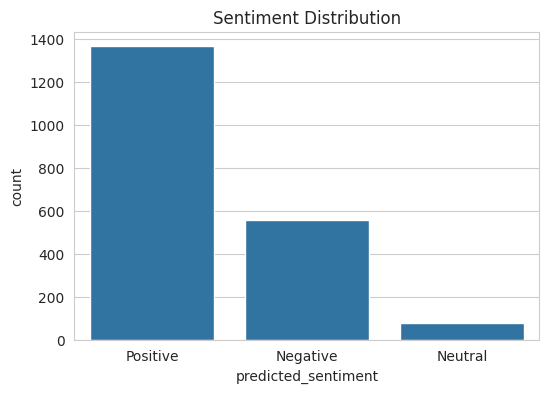

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='predicted_sentiment')

plt.title("Sentiment Distribution")
plt.show()

### Insight

Most reviews are positive, indicating overall customer satisfaction.

# 7. Visualization 2: Actual vs Predicted

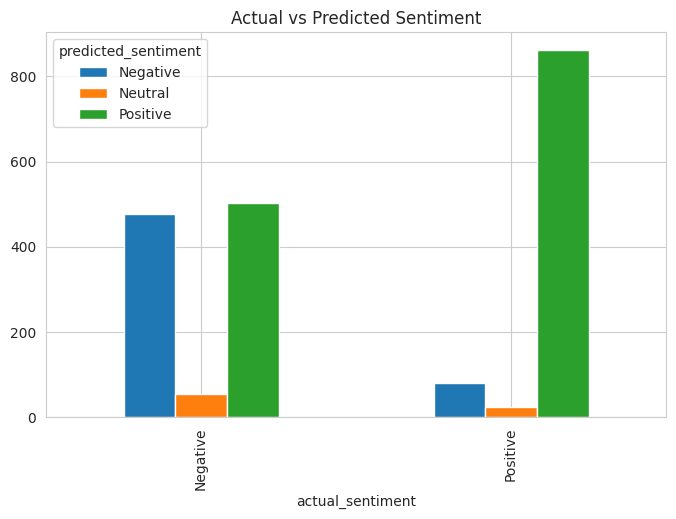

In [7]:
df['actual_sentiment'] = df['label'].map({1: "Positive", 0: "Negative"})

comparison = pd.crosstab(df['actual_sentiment'], df['predicted_sentiment'])

comparison.plot(kind='bar', figsize=(8,5))

plt.title("Actual vs Predicted Sentiment")
plt.show()

### Insight

VADER performs reasonably well in classifying general sentiment.

# 8. WordCloud

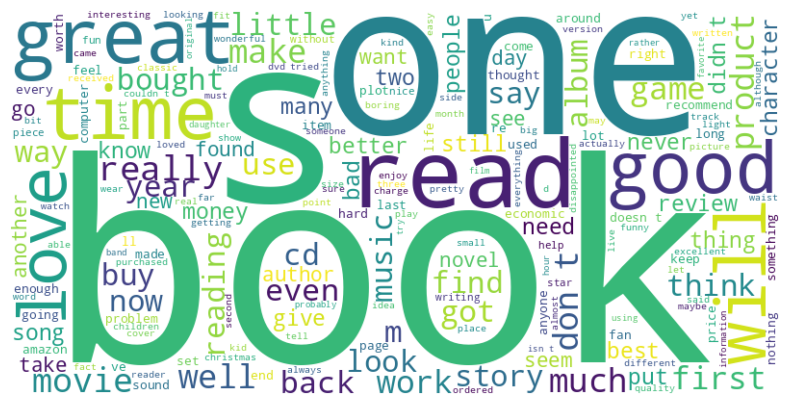

In [16]:
text = " ".join(df['cleaned_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)



plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Insight

Frequent words highlight product experience, delivery, and satisfaction trends.

## Final Insights

- Most Amazon reviews are positive, showing high customer satisfaction.
- Negative reviews highlight product or expectation issues.
- Sentiment analysis helps businesses understand customer feedback at scale.
- VADER provides a simple and effective baseline model.
- This analysis can help improve product quality and customer experience.